In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Task 2 started successfully")

Task 2 started successfully


In [2]:
import pandas as pd
import os

base_path = os.path.dirname(os.getcwd())
file_path = os.path.join(base_path, "data", "AAPL.csv")

df = pd.read_csv(file_path)
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df[['Open','High','Low','Close','Volume']] = df[['Open','High','Low','Close','Volume']].astype(float)

## Moving Averages

This section computes Simple Moving Averages (SMA) and Exponential Moving Averages (EMA) to identify stock price trends over time.

In [6]:
# Simple Moving Averages
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# Exponential Moving Averages
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

df[['Close', 'SMA_20', 'SMA_50', 'EMA_20', 'EMA_50']].tail()

,Close,SMA_20,SMA_50,EMA_20,EMA_50
3769,191.788757,191.856618,183.572859,191.510231,186.389576
3770,191.243912,192.018094,183.858864,191.484867,186.579942
3771,191.342972,192.154308,184.149424,191.471353,186.766728
3772,191.768951,192.362839,184.479567,191.499696,186.962893
3773,190.728775,192.490633,184.814828,191.426275,187.110575


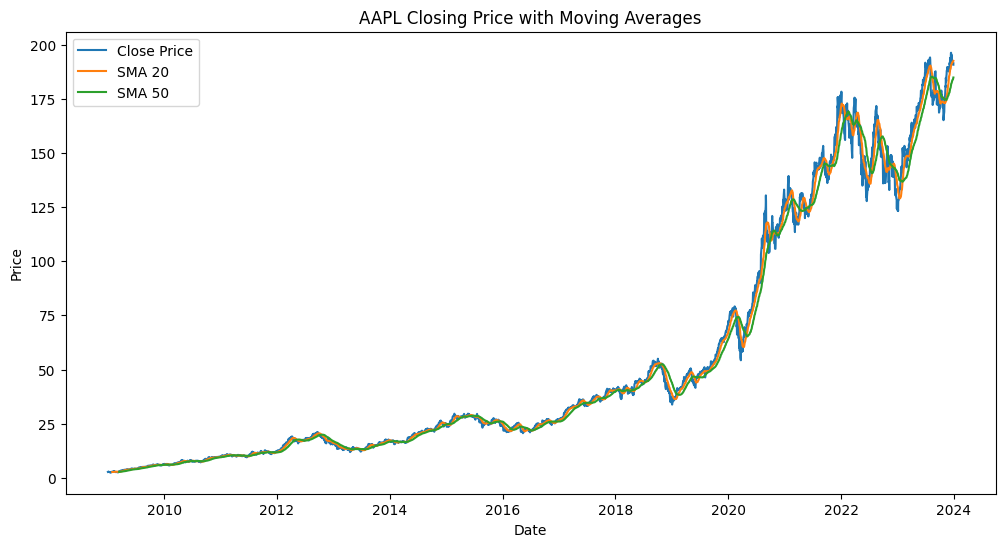

In [7]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['SMA_20'], label='SMA 20')
plt.plot(df['Date'], df['SMA_50'], label='SMA 50')

plt.title("AAPL Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()